# CIFAR10 with CNNs
---
## Equipe 8:
> Almir Alves: aasc     <br>
  Erbert Gadelha: ebgr  <br>
  Felipe Mateus: fmfb   <br>
  João Pedro: jpba      <br>
  Vinicius Barbosa: vrb <br>

# 1 - Parâmetros Iniciais do projeto base

> Adicionar aspas




###input_size:

- Valor inicial: 32 * 32 * 3 = 3072

- Objetivo: medir dimensão das imagens CIFAR-10: 32x32 pixels, 3 canais RGB

###num_classes:

- Valor: 10

- Objetivo: definir o número de classes no CIFAR-10. Está implementado diretamente em:

```
self.fc_output = nn.Linear(84, 10)
```

###learning_rate:

- Valor: 0.001

- Objetivo: definir a taxa de velocidade de treinamento

###num_epochs:

- Valor: 10

- Objetivo: medir quantas vezes todas as amostras passarão por treinamento

###batch_size:

- Valor: 32

- Objetivo: definir a quantidade de amostras por fluxo de treinamento


###Estruturação das camadas:

- self.conv1: Recebe imagens com 3 canais RGB. Aplicam-se 32 filtros de tamanho 3 x 3, onde cada um aprende um padrão diferente. Após aplicação do self.pool, terá uma saída de 32 x 16 x 16 neurônios.

```
self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
```

- self.conv2: recebe 32 filtros e aplica 64 filtros de tamanho 3 x 3 sobre eles. Após aplicação do self.pool, terá uma saída de 64 x 8 x 8 neurônios.

```
self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
```

- self.pool: Mantém o maior valor em blocos 2 x 2 (max pooling) e reduz pela metade a altura e a largura da imagem (stride = 2) para cada camada convolucional.

```
self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
```

- self.fc_hidden1: Primeira camada oculta, de 4096 (64 x 8 x 8) para 120 neurônios.

```
self.fc_hidden1 = nn.Linear(64 * 8 * 8, 120)
```

- self.fc_hidden2: Segunda camada oculta, de 120 para 84 neurônios.

```
self.fc_hidden2 = nn.Linear(120, 84)`
```

- self.fc_output: Camada de saída, de 84 para num_classes (10 para CIFAR-10).

```
self.fc_output = nn.Linear(84, 10)
```

###Funções de Ativação e Perda

- activation_function: nn.ReLU()

```
Cálculo: f(x) = x para x > 0, 0 caso contrário
```

- loss_function: nn.CrossEntropyLoss()

```
Cálculo: negativo do logaritmo da probabilidade prevista para a classe correta
```

Observação: todos os valores de métricas a seguir foram medidos com base nos dados do conjunto de testes


## Teste Inicial
Tendo como base apenas o teste com os valores padrões, foi obtido em 2 minutos e 40 segundos de execução uma taxa média final de perda de 0.1874, obtendo valores de métrica muito superiores ao MLP:

```
Scores of your model
 {'accuracy': 0.6991, 'balanced_accuracy': np.float64(0.6990999999999999), 'precision': 0.7065330319437901, 'recall': 0.6991, 'f1_score': 0.6998097397518164}
 ```

# 2 - Alterando a função de ativação



###1. LeakyReLU( )

Visando eliminar o problema causado pela morte de neurônios em entradas negativas aplicamos a função de ativação leakyReLU(). Nela, valores abaixo de 0 são multiplicados por uma constante, diminuindo seu efeito na propagação de dados, porém não anulando sua atuação, uma vez que se mantém o cálculo de gradientes. Lembrando, funções de ativação introduzem não-linearidade no modelo, permitindo aprender padrões complexos. Com taxa de erro médio de 0.1335, foram obtidas as seguintes métricas:

```
Scores of your model
 {'accuracy': 0.7276, 'balanced_accuracy': 0.7276, 'precision': 0.7280877130389911, 'recall': 0.7276, 'f1_score': 0.7265243441585986`}
```

###2. ELU( )

Aplicando a função nn.ELU(), funciona similar ao LeakyRELU, porém com forma exponencial com ativação mais suave e centrada em zero (melhora a convergência). Seu cálculo é da forma:

```
f(x) = a(e^x - 1)
```

Com taxa de perda média final de 0.1476, obtemos as seguinte métricas usando ELU:

```
Scores of your model
 {'accuracy': 0.707, 'balanced_accuracy': 0.7070000000000001, 'precision': 0.7103413580966371, 'recall': 0.707, 'f1_score': 0.707637929058539}
```
Seguindo o treinamento que foi realizado no modelo com MLP, foi-se implementada uma camada escondida extra.

```
self.fc_input = nn.Linear(64 * 8 * 8, 128)
self.fc_hidden1 = nn.Linear(128, 256)
self.fc_hidden2 = nn.Linear(256, 128)
self.fc_hidden3 = nn.Linear(128, 64)
self.fc_output = nn.Linear(64, 10)
 ```

 Treinando com LeakyReLU, com taxa de perda média final de 0.1650, foram obtidas as seguintes métricas:

```
Scores of your model
 {'accuracy': 0.7231, 'balanced_accuracy': 0.7231, 'precision': 0.7288166274245367, 'recall': 0.7231, 'f1_score': 0.7237624521057013}
```

 Enquanto com ELU, com taxa média de perda final de 0.1829, foi obtido:

 ```
 Scores of your model
 {'accuracy': 0.7095, 'balanced_accuracy': 0.7095, 'precision': 0.7158495099885597, 'recall': 0.7095, 'f1_score': 0.7117117183329135}
 ```
 Assim, foi-se decidido manter a estrutura original de camadas internas e utilizar o LeakyReLU, uma vez que as taxas apresentadas foram as melhores.

## Dropout
Após isso, foi-se implementado dropout após cada camada interna. Após uma série de testes, o seguinte conjunto de dropouts auxilia no aumento da acurácia sem penalizar tanto a taxa de perda média final (0.3606).

```
self.fc_hidden1 = nn.Linear(64 * 8 * 8, 120)
self.dropout1 = nn.Dropout(p=0.25)
self.fc_hidden2 = nn.Linear(120, 84)
self.dropout2 = nn.Dropout(p=0.15)
self.fc_output = nn.Linear(84, 10)
```

As métricas obtidas foram as seguintes:
```
Scores of your model
{'accuracy': 0.7442, 'balanced_accuracy': np.float64(0.7442000000000001), 'precision': 0.7414908068207763, 'recall': 0.7442, 'f1_score': 0.7418330680354339}
```

##Num_epochs
Aumentando o número de épocas, é possível durar por mais tempo o treinamento. Entretanto, para evitar overfitting, são precias implementações extras como:

- Data augmentation: aumento artificial da diversidade dos dados de treino
- Scheduler: ajusta automaticamente o learning_rate ao longo das épocas.

Assim, mesmo com taxa média de perda de aprendizagem de 0.6822 (uma vez que o treinamento fica mais difícil), é possível adquirir as seguintes métricas:
```
Scores of your model
 {'accuracy': 0.8022, 'balanced_accuracy': np.float64(0.8022), 'precision': 0.8035697748931844, 'recall': 0.8022, 'f1_score': 0.8008207532440909}
 ```

##Redução da taxa de erro médio
Em busca de diminuir a taxa de erro médio do modelo, foram implementados:

- Batch Normalization: normaliza cada batch por meio de uma média dos dados internos, deixando o treinamento mais rápido e estável.

- Global Average Pooling: reduz o número de parâmetros de camadas densas por meio de uma média dos dados de ativação

Assim, a taxa de erro médio passou a ser 0.5415, por mais que as métricas tenham se mantido.

```
Scores of your model
 {'accuracy': 0.8063, 'balanced_accuracy': np.float64(0.8063), 'precision': 0.8074096032837748, 'recall': 0.8063, 'f1_score': 0.805642736297445}
```

# 3 - Teste final e execução
Para finalizar os treinamentos do modelo, foram adicionadas duas camadas extras na CNN, totalizando 5 camadas de CNN, 2 camadas escondidas e 1 camada de output. Assim, os finais obtidos, com taxa de erro médio de 0.3467, foram

```
Scores of your model
{'accuracy': 0.8549, 'balanced_accuracy': np.float64(0.8549), 'precision': 0.8568685801622893, 'recall': 0.8549, 'f1_score': 0.8551759681489979}
```

## 3.1 Carregando DataSet

In [ ]:
#@title Libs

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

from tqdm import tqdm

In [ ]:
#@title Dataset Setup

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),                                          # flip horizontal aleatório
    transforms.RandomResizedCrop(32, scale=(.7, 1)),                            # resize aleatorio
    transforms.ColorJitter(brightness=(.7,1), contrast=(1,1.5), saturation=0),  # alterações na cor
    transforms.ToTensor(),                                                      # normaliza para [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))                      # normaliza para [-1,1]
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)

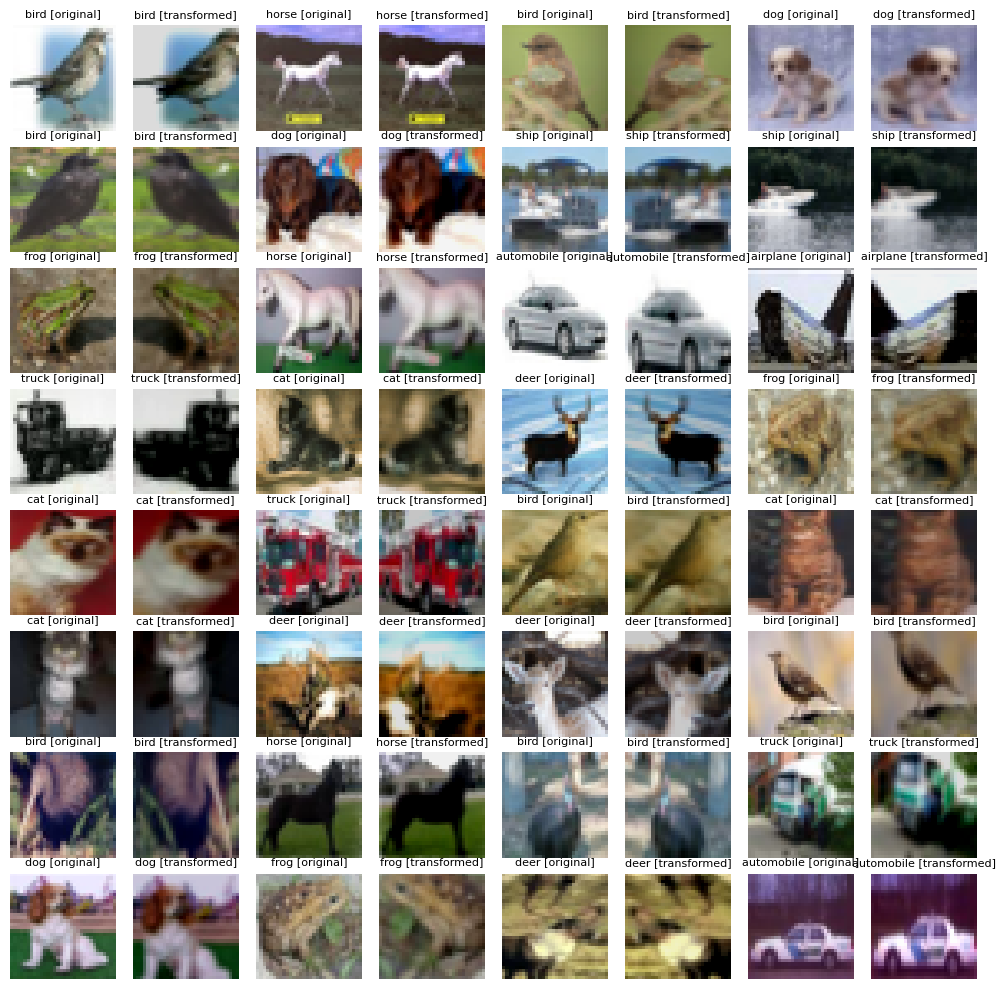

In [ ]:
#@title Vizualization

W_grid = 8
L_grid = 8

fig, axes = plt.subplots(L_grid, W_grid, figsize=(10, 10))
axes = axes.ravel()

n_train = len(train_dataset)

for i in range(int((W_grid * L_grid)/2)):
    index = np.random.randint(0, n_train)

    axes[i*2].imshow(train_dataset.data[index])
    axes[i*2].set_title(train_dataset.classes[train_dataset.targets[index]] + ' [original]', fontsize=8)
    axes[i*2].axis('off')

    image_tensor, label = train_dataset[index]
    image = image_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[(i*2)+1].imshow(image)
    axes[(i*2)+1].set_title(train_dataset.classes[label] + ' [transformed]', fontsize=8)
    axes[(i*2)+1].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.15)
plt.show()

## 3.2 Defining the CNN model

Here we adapt the LeNet-5 architecture introduced in [*Gradient-based learning applied to document recognition*](https://ieeexplore.ieee.org/document/726791), originally developed to classify handwritten digits.

![lenet5](https://www.researchgate.net/publication/359784095/figure/fig2/AS:11431281079624737@1660789284522/Example-of-a-CNN-LeNet-5-14-is-able-to-identify-handwritten-digits-for-zip-code.png)


The main change we made here is the number of in/out channels, kernel sizes, padding, etc (enabling better results). It has 2 convolutional layers followed by 2 pooling (subsampling) layers. After the conv. blocks, we pass the feature maps through 2 hidden fully-connected layers to get the most activated neuron with the softmax function. If you want a more detailed explanation, [check this link](https://www.datasciencecentral.com/lenet-5-a-classic-cnn-architecture/) or reach us on Discord :)

In [ ]:
#@title 3.2.1 CNN Model

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        self.leaky_relu = nn.LeakyReLU(0.1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_hidden1 = nn.Linear(128, 120)
        self.dropout1 = nn.Dropout(p=0.25)

        self.fc_hidden2 = nn.Linear(120, 84)
        self.dropout2 = nn.Dropout(p=0.15)

        self.fc_output = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(self.leaky_relu(self.bn1(self.conv1(x))))
        x = self.pool(self.leaky_relu(self.bn2(self.conv2(x))))
        x = self.pool(self.leaky_relu(self.bn3(self.conv3(x))))
        x = self.pool(self.leaky_relu(self.bn4(self.conv4(x))))
        x = self.pool(self.leaky_relu(self.bn5(self.conv5(x))))

        x = self.global_avg_pool(x) #novo
        x = x.view(x.size(0), -1)

        x = self.leaky_relu(self.fc_hidden1(x))
        x = self.dropout1(x)

        x = self.leaky_relu(self.fc_hidden2(x))
        x = self.dropout2(x)
        x = self.fc_output(x)
        return x

In [ ]:
#@title 3.2.2 Defining metrics helper

def get_scores(targets, predictions):
    return {
        "accuracy": metrics.accuracy_score(targets, predictions),
        "balanced_accuracy": metrics.balanced_accuracy_score(targets, predictions),
        "precision": metrics.precision_score(targets, predictions, average="weighted"),
        "recall": metrics.recall_score(targets, predictions, average="weighted"),
        "f1_score": metrics.f1_score(targets, predictions, average="weighted")
    }

In [ ]:
#@title 3.2.3 Hyperparameters

learning_rate = 0.001
num_epochs = 30
batch_size = 32
# Learning rate scheduler


loss_function = nn.CrossEntropyLoss()

In [ ]:
#@title Loaders

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
#@title 3.2.4 Training loop

# Build the model
cnn = CNN()
cnn.cuda()

# Setting optimizer up
optimizer = torch.optim.Adam(cnn.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

# Early stopping setup
best_loss = float('inf')
patience = 5
patience_counter = 0

# Start training epochs loop
for epoch in tqdm(range(num_epochs)):
  epoch_loss = 0.0
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()

    # Forward pass
    optimizer.zero_grad()
    outputs = cnn(images)

    # Backward pass
    loss = loss_function(outputs, labels)
    loss.backward()

    optimizer.step()

    epoch_loss += loss.item()

    if (i+1) % 1000 == 0:
      tqdm.write(f' Epoch {epoch + 1}/{num_epochs}, Step {i+1}/{len(train_dataset) // batch_size}, Loss: {loss}')

  # Loss avrg
  epoch_loss /= len(train_loader)
  tqdm.write(f' Epoch {epoch+1} average loss: {epoch_loss:.4f}')

  scheduler.step(epoch_loss)

  # Early stopping using loss
  if epoch_loss < best_loss:
      best_loss = epoch_loss
      patience_counter = 0
      torch.save(cnn.state_dict(), 'cnn_weights.pth')
  else:
      patience_counter += 1
      if patience_counter >= patience:
          tqdm.write("Early stopping triggered.")
          break

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  0%|          | 0/30 [00:17<?, ?it/s]

 Epoch 1/30, Step 1000/1562, Loss: 1.0742955207824707


  3%|▎         | 1/30 [00:27<13:08, 27.21s/it]

 Epoch 1 average loss: 1.4284


  3%|▎         | 1/30 [00:44<13:08, 27.21s/it]

...

 Epoch 29 average loss: 0.3538


 97%|█████████▋| 29/30 [13:34<00:27, 27.43s/it]

 Epoch 30/30, Step 1000/1562, Loss: 0.39560097455978394


100%|██████████| 30/30 [13:44<00:00, 27.49s/it]

 Epoch 30 average loss: 0.3467


In [ ]:
#@title 3.2.5 Evaluate model (accuracy, precision, recall, etc)

cnn.eval()
predictions = []
labels = []
for images, label in test_loader:
  images = images.cuda()
  label = label.cuda()

  output = cnn(images)
  _, predicted = torch.max(output,1)

  predictions.extend(predicted.cpu().numpy())
  labels.extend(label.cpu().numpy())

scores = get_scores(labels, predictions)
print("Scores of your model\n", scores)

Scores of your model
 {'accuracy': 0.8549, 'balanced_accuracy': np.float64(0.8549), 'precision': 0.8568685801622893, 'recall': 0.8549, 'f1_score': 0.8551759681489979}


## 3.3 Grid Search

In [ ]:
#@title 3.3.1  Grid

grid = {
   "activation_function": [nn.ReLU(), nn.Sigmoid()],
   "optimizer": [torch.optim.Adam, torch.optim.SGD],
   "learning_rate": [0.001, 0.01, 0.1]
}

In [ ]:
#@title 3.3.2 Training (grid search)

all_scores = []

for activation_function in grid["activation_function"]:
  for optimizer in grid["optimizer"]:
    for learning_rate in grid["learning_rate"]:
      print(f"Training with activation function: {activation_function}, optimizer: {optimizer}, learning rate: {learning_rate}")
      cnn = train_cnn(learning_rate, num_epochs, patience, loss_function, optimizer, activation_function)

      scores = evaluate_cnn(cnn)
      all_scores.append(
          {
              "activation_function": activation_function,
              "optimizer": optimizer,
              "learning_rate": learning_rate,
          }.update(scores)
      )

Training with activation function: Sigmoid(), optimizer: <class 'torch.optim.adam.Adam'>, learning rate: 0.001


  0%|          | 1/1000 [00:14<3:55:17, 14.13s/it]

 Epoch 1 average loss: 2.1132


  0%|          | 2/1000 [00:28<3:56:34, 14.22s/it]

 Epoch 2 average loss: 1.6830


...

 Epoch 228 average loss: 0.0010


 23%|██▎       | 229/1000 [52:49<2:54:12, 13.56s/it]

 Epoch 229 average loss: 0.0010


 23%|██▎       | 229/1000 [53:03<2:58:37, 13.90s/it]


 Epoch 230 average loss: 0.0010
Early stopping triggered.
Scores of your model
 {'accuracy': 0.6732, 'balanced_accuracy': np.float64(0.6732000000000001), 'precision': 0.6721817926480107, 'recall': 0.6732, 'f1_score': 0.6726032223437128}


In [ ]:
#@title 3.3.3 Saving results
results = all_scores.set_index(['activation_function', 'optimizer', 'learning_rate'])
results

accuracy  balanced_accuracy  \
activation_function optimizer learning_rate                                
ReLU                Adam      0.001            0.6898             0.6898   
                              0.010            0.1000             0.1000   
                              0.100            0.1000             0.1000   
                    SGD       0.001            0.6915             0.6915   
                              0.010            0.7200             0.7200   
                              0.100            0.7262             0.7262   
Sigmoid             Adam      0.001            0.6287             0.6287   
                              0.010            0.1000             0.1000   
                              0.100            0.1000             0.1000   
                    SGD       0.001            0.1000             0.1000   
                              0.010            0.1000             0.1000   
                              0.100            0.6732             0.6732   

                                             precision  recall  f1_score  
activation_function optimizer learning_rate                               
ReLU                Adam      0.001           0.695512  0.6898  0.691207  
                              0.010           0.010000  0.1000  0.018182  
                              0.100           0.010002  0.1000  0.018185  
                    SGD       0.001           0.692525  0.6915  0.691893  
                              0.010           0.718513  0.7200  0.719066  
                              0.100           0.726273  0.7262  0.725961  
Sigmoid             Adam      0.001           0.632506  0.6287  0.629725  
                              0.010           0.010000  0.1000  0.018182  
                              0.100           0.010000  0.1000  0.018182  
                    SGD       0.001           0.010000  0.1000  0.018182  
                              0.010           0.010000  0.1000  0.018182  
                              0.100           0.672182  0.6732  0.672603

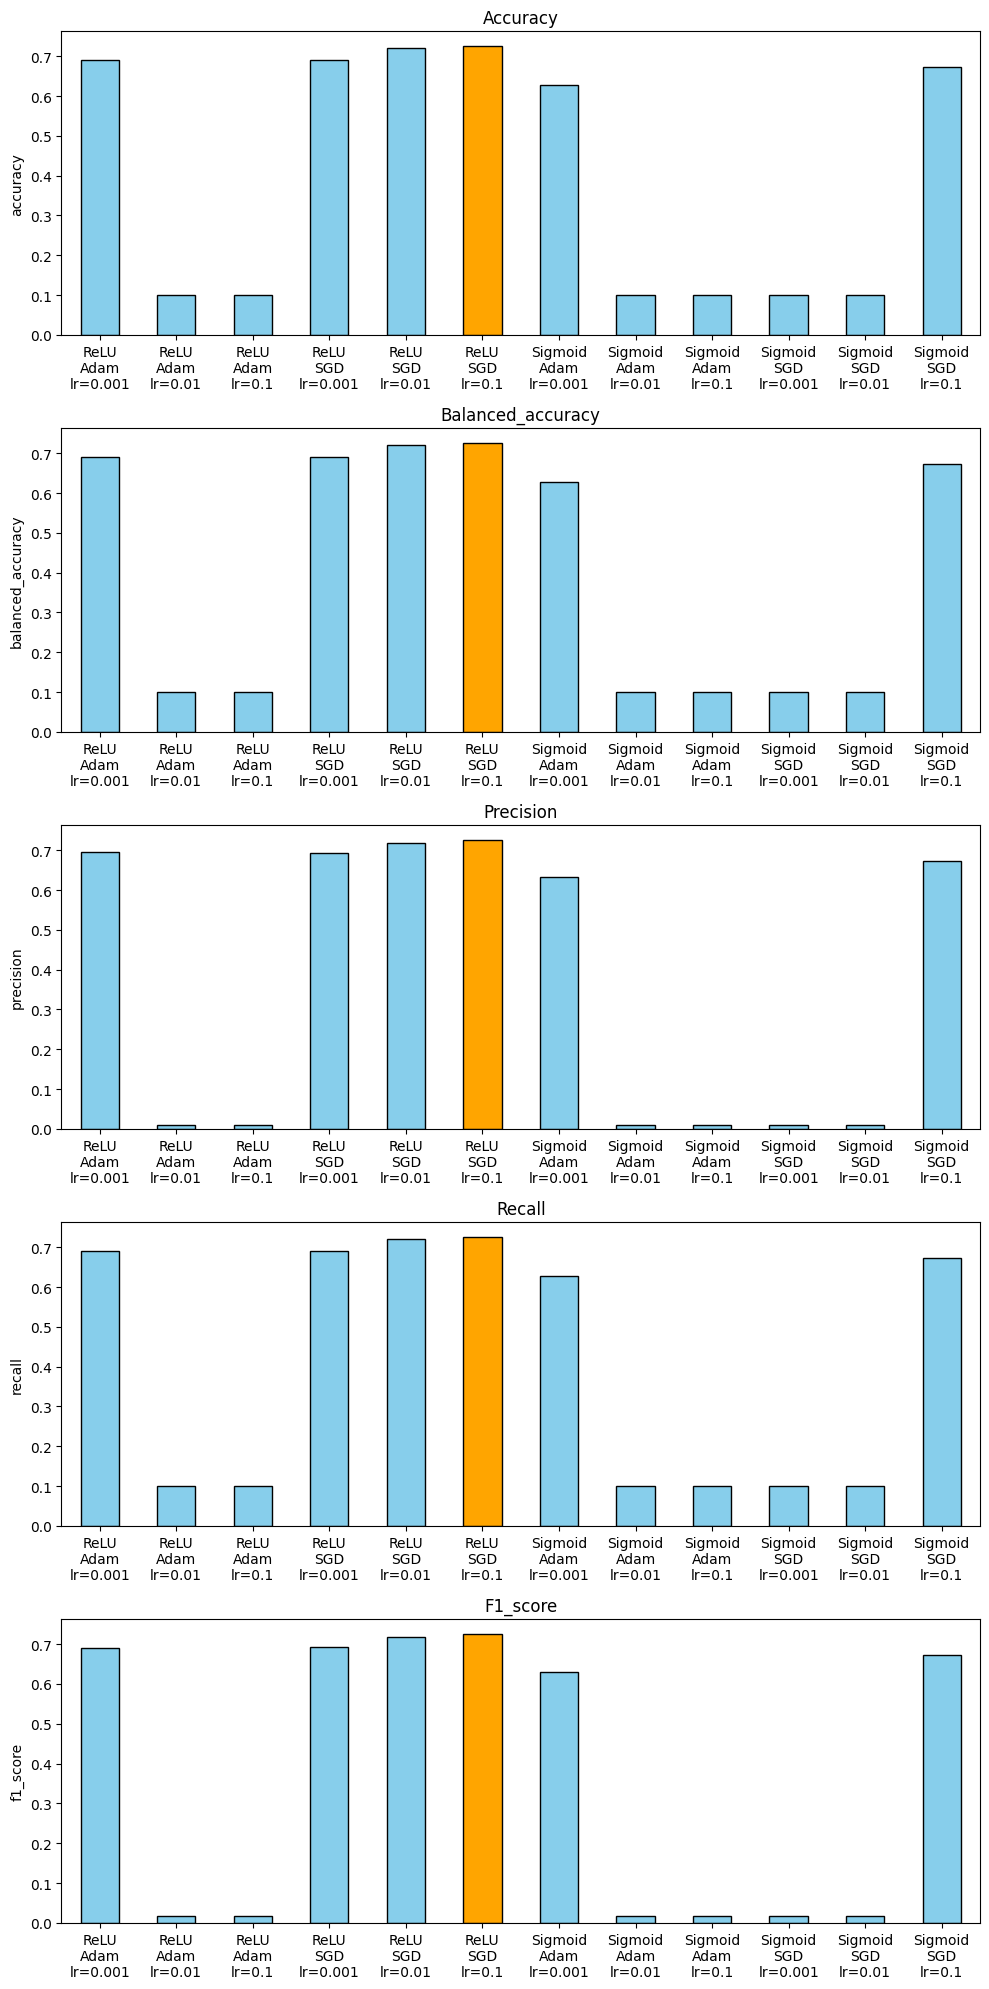

In [ ]:
#@title 3.3.4 Scores

metrics = results.columns
fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 20))

for ax, metric in zip(axes, metrics):
    values = results[metric]
    colors = ['skyblue'] * len(values)

    if metric == 'avg_loss':
        best_idx = values.idxmin()
    else:
        best_idx = values.idxmax()

    best_pos = list(values.index).index(best_idx)
    colors[best_pos] = 'orange'

    values.plot(
        kind='bar',
        ax=ax,
        title=metric.capitalize(),
        color=colors,
        edgecolor='black'
    )
    ax.set_ylabel(metric)
    ax.set_xlabel('')

    # Improve x-axis labels
    ax.set_xticklabels(
        [f'{a}\n{o}\nlr={lr}' for a, o, lr in results.index],
        rotation=0,
        ha='center'
    )

plt.tight_layout()
plt.show()

## 3.4 Matriz de Confusão
| CNN | MLP |
|---------|----------|
| 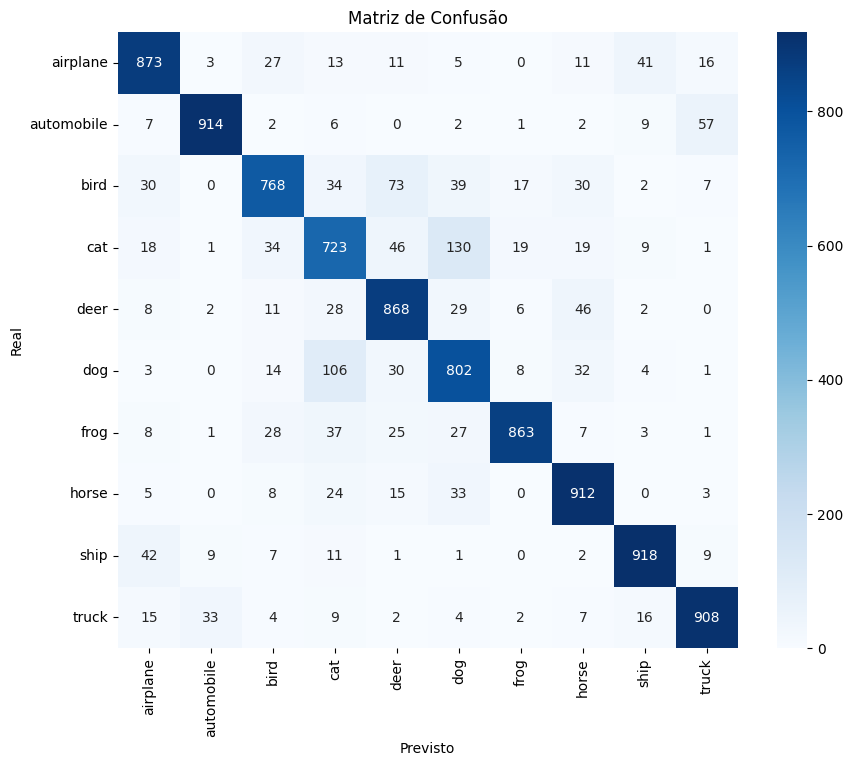|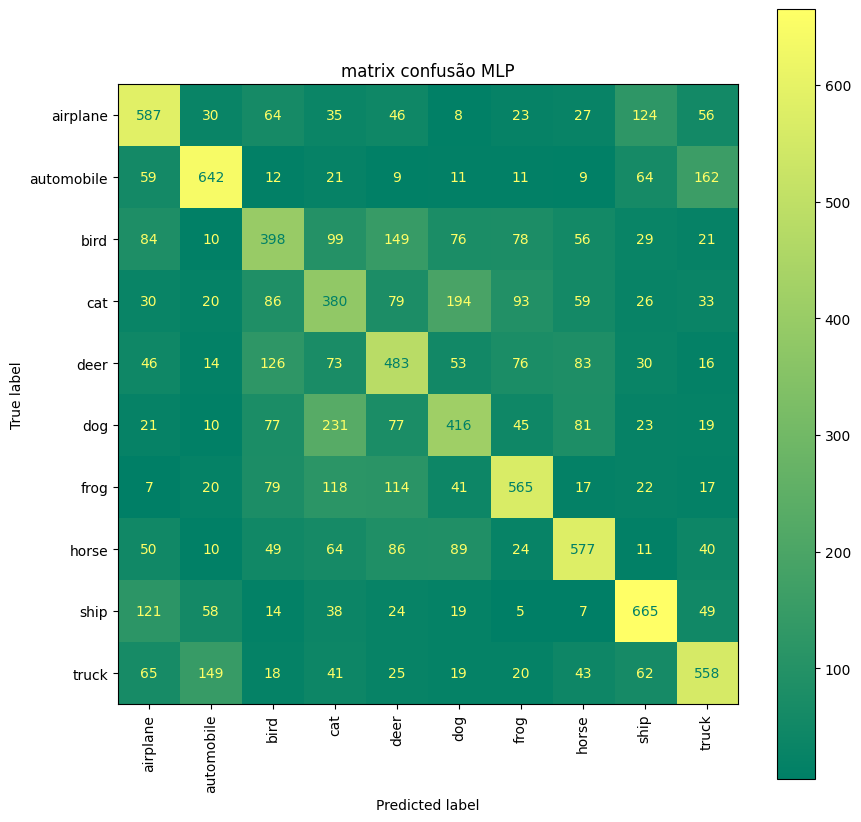|

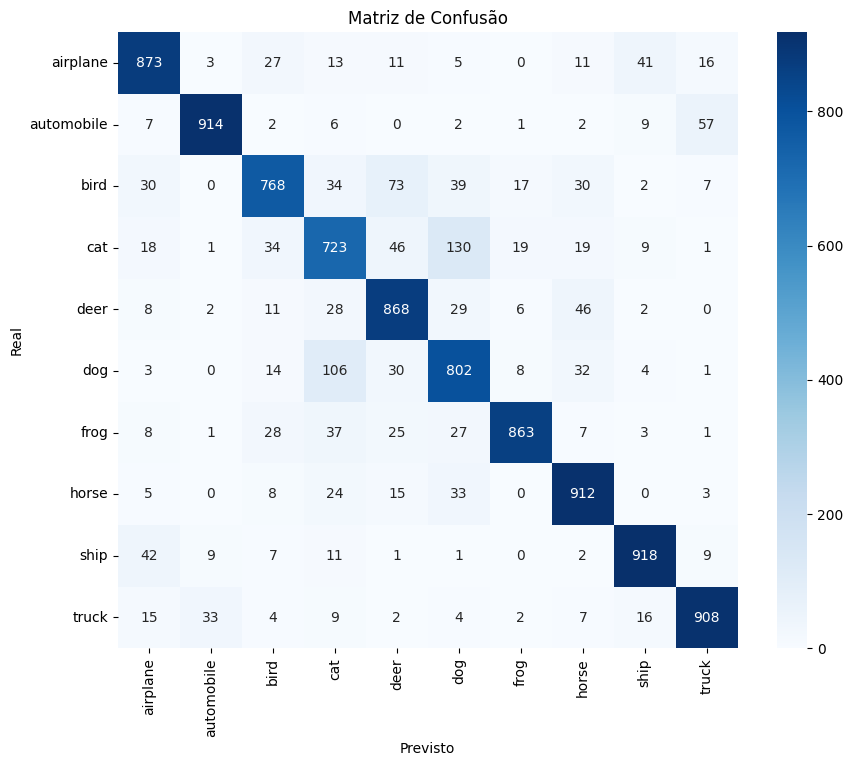

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, predictions)
classes = train_dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


##  3.5 Classificando Imagens

|  CNN |  MLP |
| ---- | ---- |
| 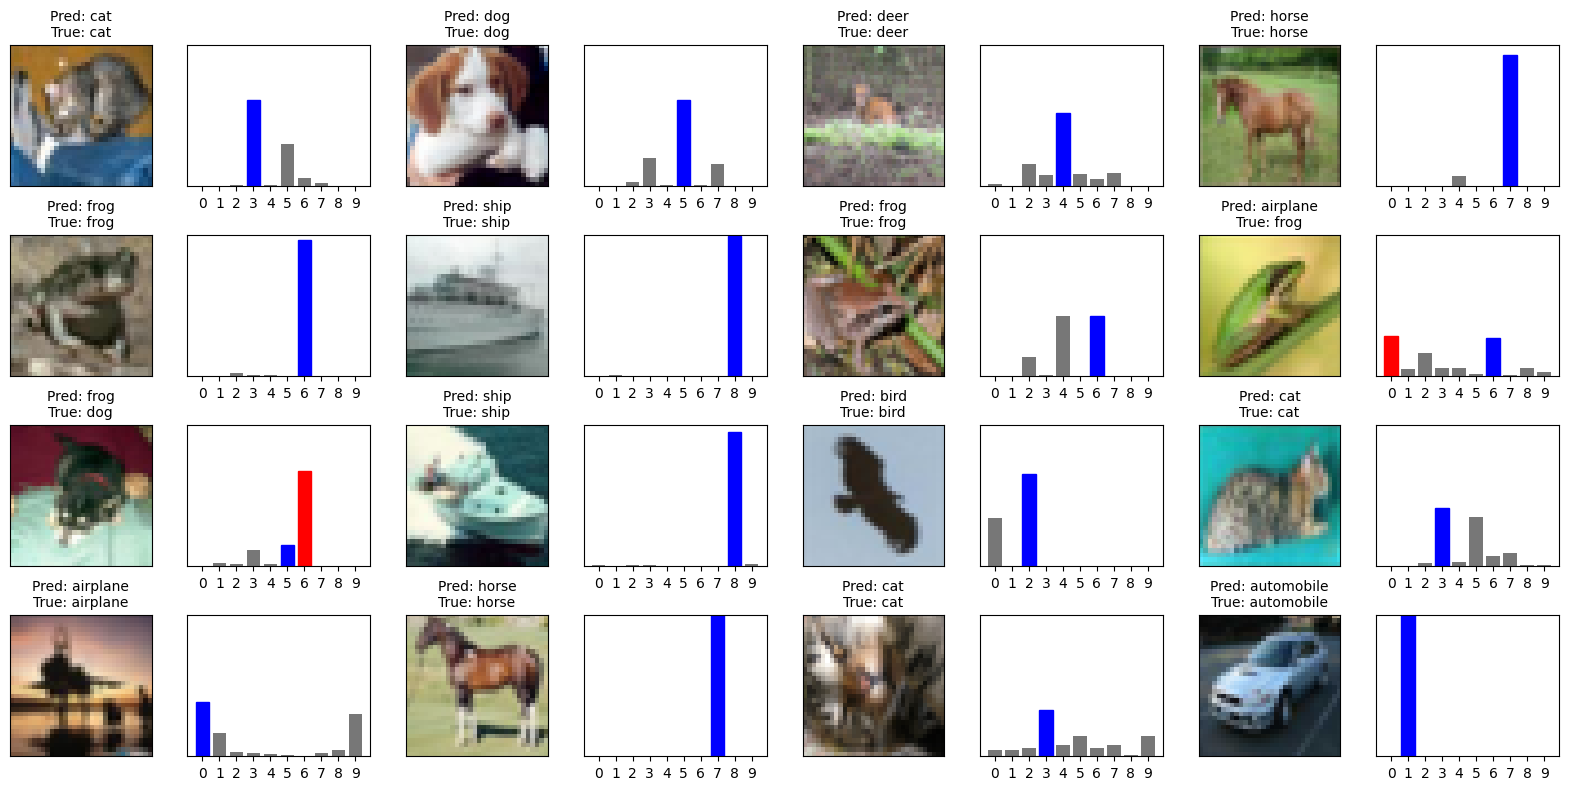 | 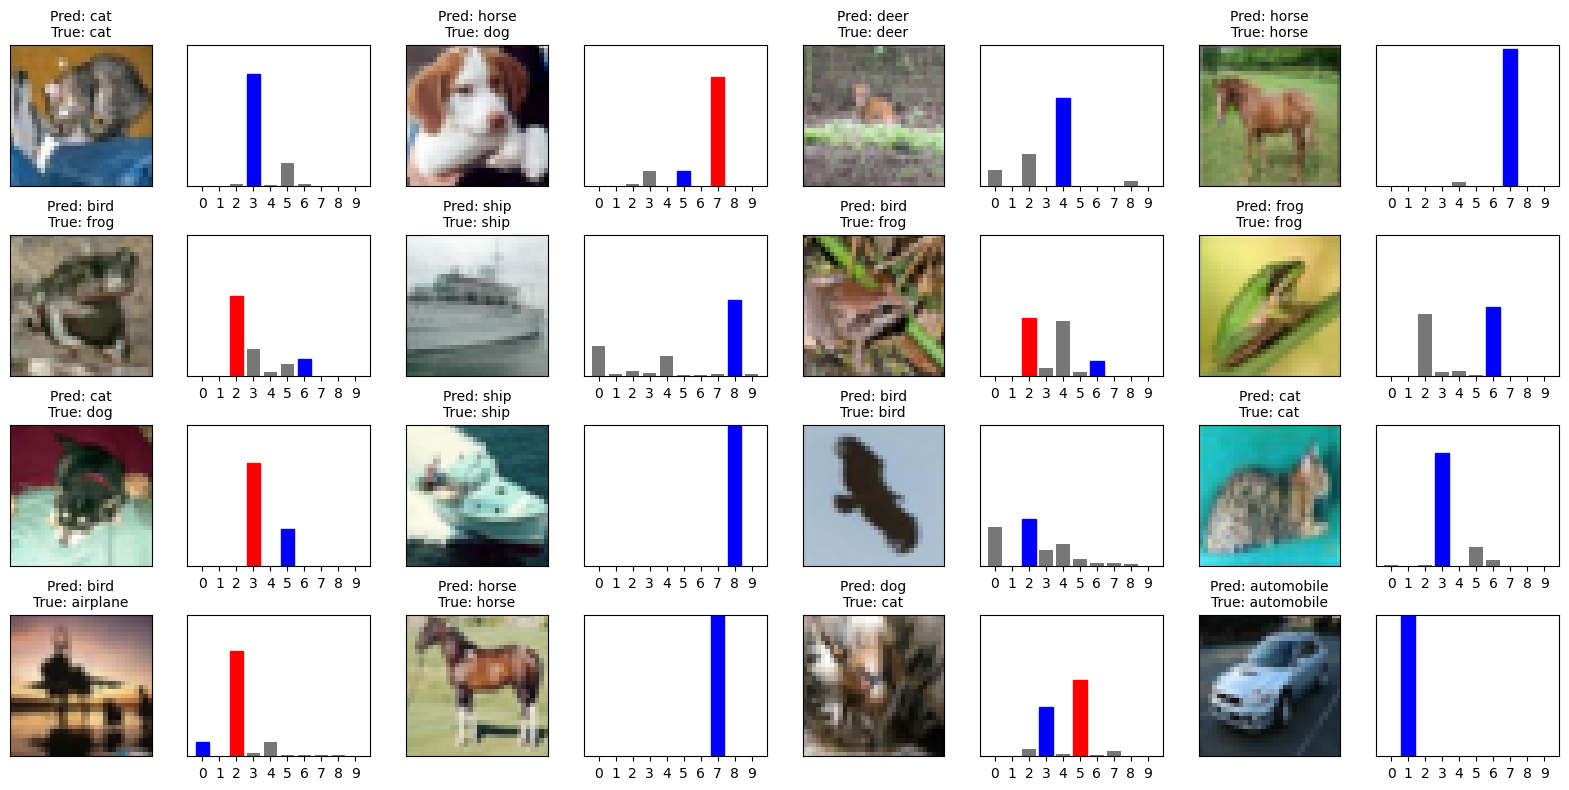 |

In [ ]:
#@title Definição dos Métodos

import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch

def plot_value_array(predictions_array, true_label):
    true_label = int(true_label)
    predicted_label = np.argmax(predictions_array)

    plt.grid(False)
    plt.xticks(range(len(predictions_array)))
    plt.yticks([])
    bars = plt.bar(range(len(predictions_array)), predictions_array, color="#777777")
    plt.ylim([0, 1])

    bars[predicted_label].set_color('red')
    bars[true_label].set_color('blue')

def plot_tests():
    cnn.eval()
    num_rows = 4
    num_cols = 4
    num_images = num_rows * num_cols

    fig = plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
    classes = train_dataset.classes

    with torch.no_grad():
        for i, (image, label) in enumerate(test_loader):
            if i >= num_images:
                break

            image_vis = image[0].cpu() * 0.5 + 0.5
            image_vis = image_vis.permute(1, 2, 0)

            cnn.eval()
            with torch.no_grad():
                output = cnn(image)                                 # saída bruta (logits)
                probabilities = F.softmax(output, dim=1)[0]         # aplica softmax
                top_prob, top_idx = torch.topk(probabilities, len(probabilities))  # índices de maior probabilidade

            # Plot da imagem classificada
            plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
            plt.grid(False)
            plt.xticks([])
            plt.yticks([])

            true_label = label[0].item()
            pred_label = predicted[0].item()

            pred_label = top_idx[0] #  predicted[0].item()
            title = f'Pred: {classes[pred_label]}\nTrue: {classes[true_label]}'
            plt.title(title, fontsize=10)
            #plt.imshow(image)
            plt.imshow(image_vis)  # e não image

            # Plot do gráfico de probabilidade
            plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
            plot_value_array(probabilities, true_label)

    plt.tight_layout()
    plt.show()

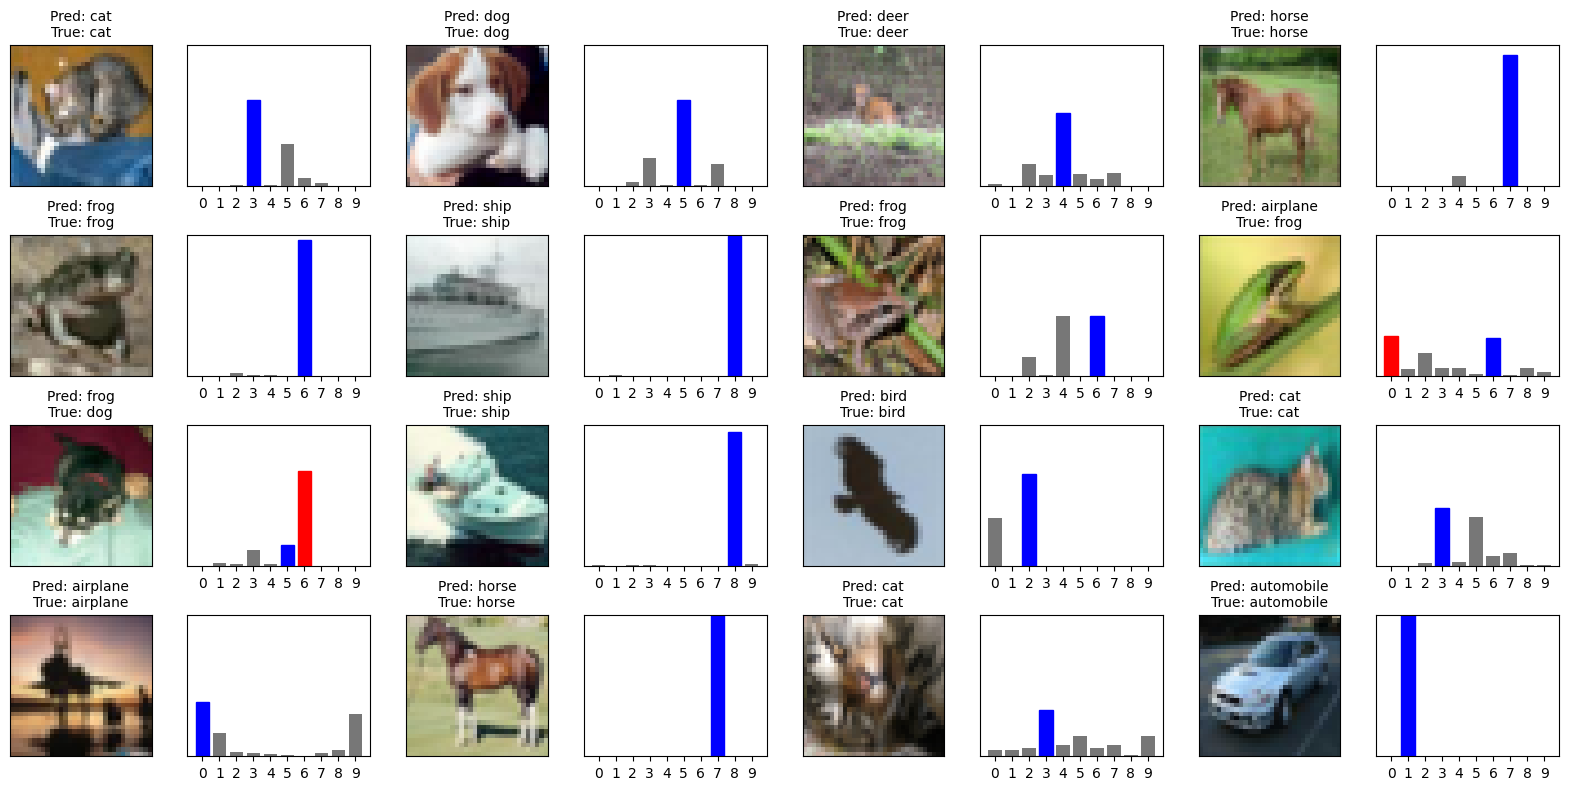

In [ ]:
plot_tests()